In [43]:
import warnings
warnings.filterwarnings('ignore')
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime

In [44]:
df=pd.read_csv(r"C:\Users\vysha\Downloads\archive (11)\Drug_overdose_death_rates__by_drug_type__sex__age__race__and_Hispanic_origin__United_States.csv")
print(df)
categorical_cols = df.select_dtypes(include=['object', 'category', 'bool'])
numerical_cols = df.select_dtypes(include=['int64', 'float64'])

#print("Categorical Columns:")
#print(categorical_cols.columns.tolist())

#print("\nNumerical Columns:")
#print(numerical_cols.columns.tolist())

                      INDICATOR                                  PANEL  \
0     Drug overdose death rates               All drug overdose deaths   
1     Drug overdose death rates               All drug overdose deaths   
2     Drug overdose death rates               All drug overdose deaths   
3     Drug overdose death rates               All drug overdose deaths   
4     Drug overdose death rates               All drug overdose deaths   
...                         ...                                    ...   
6223  Drug overdose death rates  Drug overdose deaths involving heroin   
6224  Drug overdose death rates  Drug overdose deaths involving heroin   
6225  Drug overdose death rates  Drug overdose deaths involving heroin   
6226  Drug overdose death rates  Drug overdose deaths involving heroin   
6227  Drug overdose death rates  Drug overdose deaths involving heroin   

      PANEL_NUM                                               UNIT  UNIT_NUM  \
0             0  Deaths per 100

In [45]:
df.rename(columns={
    'INDICATOR': 'MEASURE',
    'PANEL': 'DRUGTYPE',
    'PANEL_NUM': 'DRUGTYPECODE',
    'UNIT_NUM': 'UNITCODE',
    'STUB_NAME': 'CATEGORY',
    'STUB_NAME_NUM': 'CATEGORYCODE',
    'STUB_LABEL': 'SUBGROUP',
    'STUB_LABEL_NUM': 'SUBGROUPCODE',
    'YEAR_NUM': 'YEARCODE',
    'AGE': 'AGEGROUP',
    'AGE_NUM': 'AGECODE',
    'ESTIMATE': 'RATE'
}, inplace=True)
print(df)


                        MEASURE                               DRUGTYPE  \
0     Drug overdose death rates               All drug overdose deaths   
1     Drug overdose death rates               All drug overdose deaths   
2     Drug overdose death rates               All drug overdose deaths   
3     Drug overdose death rates               All drug overdose deaths   
4     Drug overdose death rates               All drug overdose deaths   
...                         ...                                    ...   
6223  Drug overdose death rates  Drug overdose deaths involving heroin   
6224  Drug overdose death rates  Drug overdose deaths involving heroin   
6225  Drug overdose death rates  Drug overdose deaths involving heroin   
6226  Drug overdose death rates  Drug overdose deaths involving heroin   
6227  Drug overdose death rates  Drug overdose deaths involving heroin   

      DRUGTYPECODE                                               UNIT  \
0                0  Deaths per 100,000

In [46]:
print(df.isnull().any())

MEASURE         False
DRUGTYPE        False
DRUGTYPECODE    False
UNIT            False
UNITCODE        False
CATEGORY        False
CATEGORYCODE    False
SUBGROUP        False
SUBGROUPCODE    False
YEAR            False
YEARCODE        False
AGEGROUP        False
AGECODE         False
RATE             True
FLAG             True
dtype: bool


In [47]:
duplicate_rows = df[df.duplicated()]
print(f"Number of duplicate rows: {duplicate_rows.shape[0]}")
print(duplicate_rows)

Number of duplicate rows: 0
Empty DataFrame
Columns: [MEASURE, DRUGTYPE, DRUGTYPECODE, UNIT, UNITCODE, CATEGORY, CATEGORYCODE, SUBGROUP, SUBGROUPCODE, YEAR, YEARCODE, AGEGROUP, AGECODE, RATE, FLAG]
Index: []


In [48]:
print(df.tail())


                        MEASURE                               DRUGTYPE  \
6223  Drug overdose death rates  Drug overdose deaths involving heroin   
6224  Drug overdose death rates  Drug overdose deaths involving heroin   
6225  Drug overdose death rates  Drug overdose deaths involving heroin   
6226  Drug overdose death rates  Drug overdose deaths involving heroin   
6227  Drug overdose death rates  Drug overdose deaths involving heroin   

      DRUGTYPECODE                                           UNIT  UNITCODE  \
6223             5  Deaths per 100,000 resident population, crude         2   
6224             5  Deaths per 100,000 resident population, crude         2   
6225             5  Deaths per 100,000 resident population, crude         2   
6226             5  Deaths per 100,000 resident population, crude         2   
6227             5  Deaths per 100,000 resident population, crude         2   

         CATEGORY  CATEGORYCODE                   SUBGROUP  SUBGROUPCODE  \
6223

In [49]:
print(df.isna().sum())

MEASURE            0
DRUGTYPE           0
DRUGTYPECODE       0
UNIT               0
UNITCODE           0
CATEGORY           0
CATEGORYCODE       0
SUBGROUP           0
SUBGROUPCODE       0
YEAR               0
YEARCODE           0
AGEGROUP           0
AGECODE            0
RATE            1111
FLAG            5117
dtype: int64


In [50]:
df['RATE'] = df['RATE'].fillna(df['RATE'].mean())
df['FLAG'] = df['FLAG'].fillna('Unknown')


In [51]:
#Remove spaces from column names
df.columns = df.columns.str.replace(' ','_')

In [52]:
 #Check for duplicate rows
df.duplicated().sum()

0

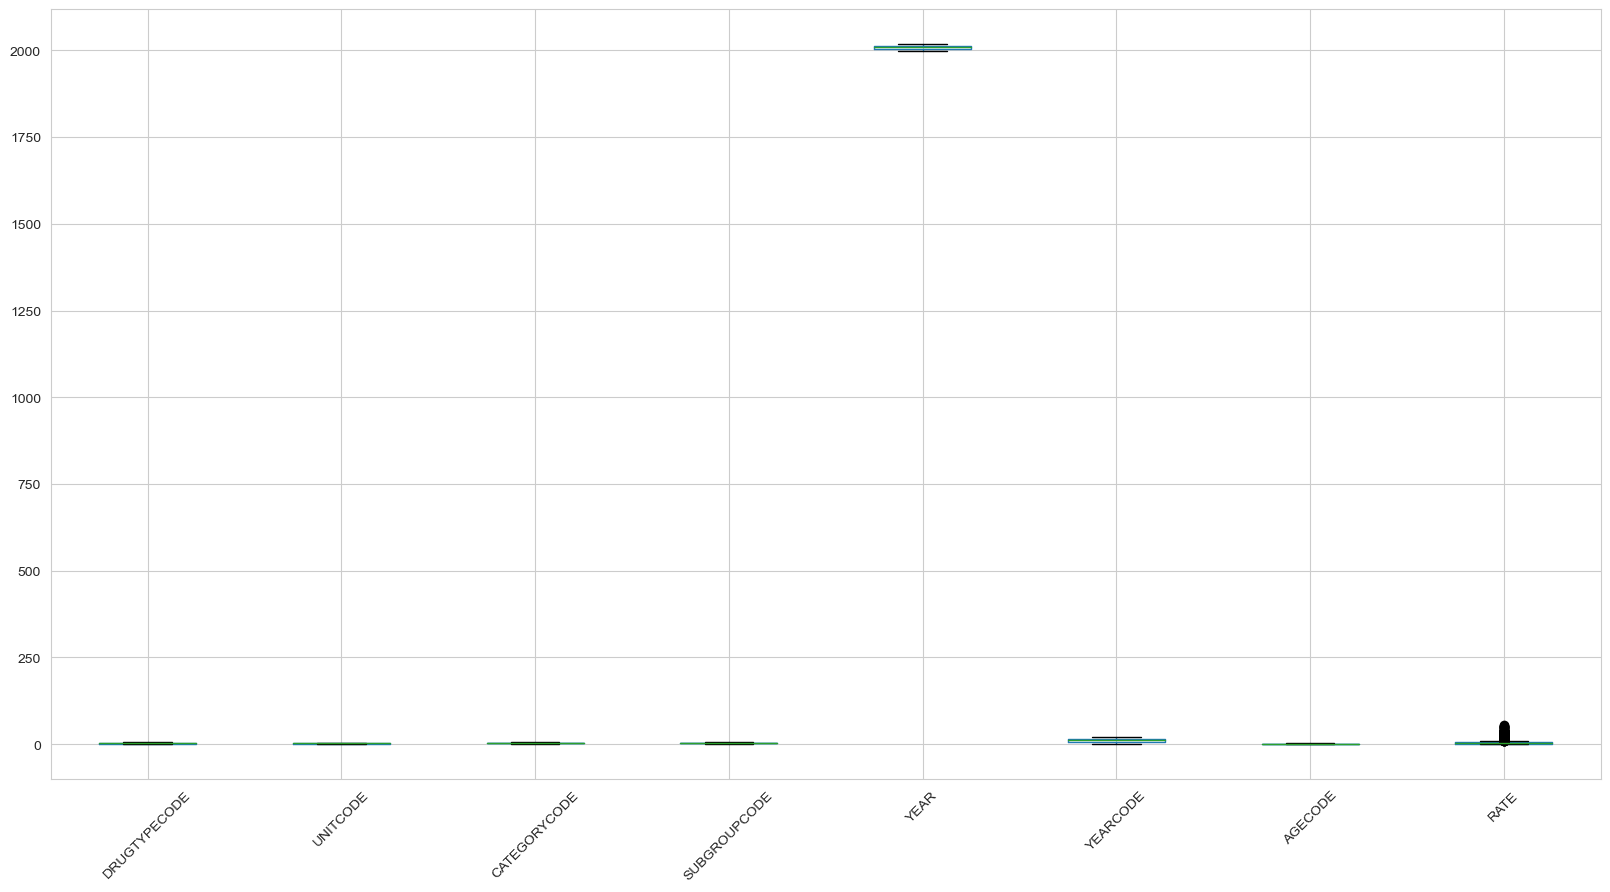

In [53]:
# plot boxplot for checking outliers
df.boxplot(figsize=(20,10))
plt.xticks(rotation=45)
plt.show()

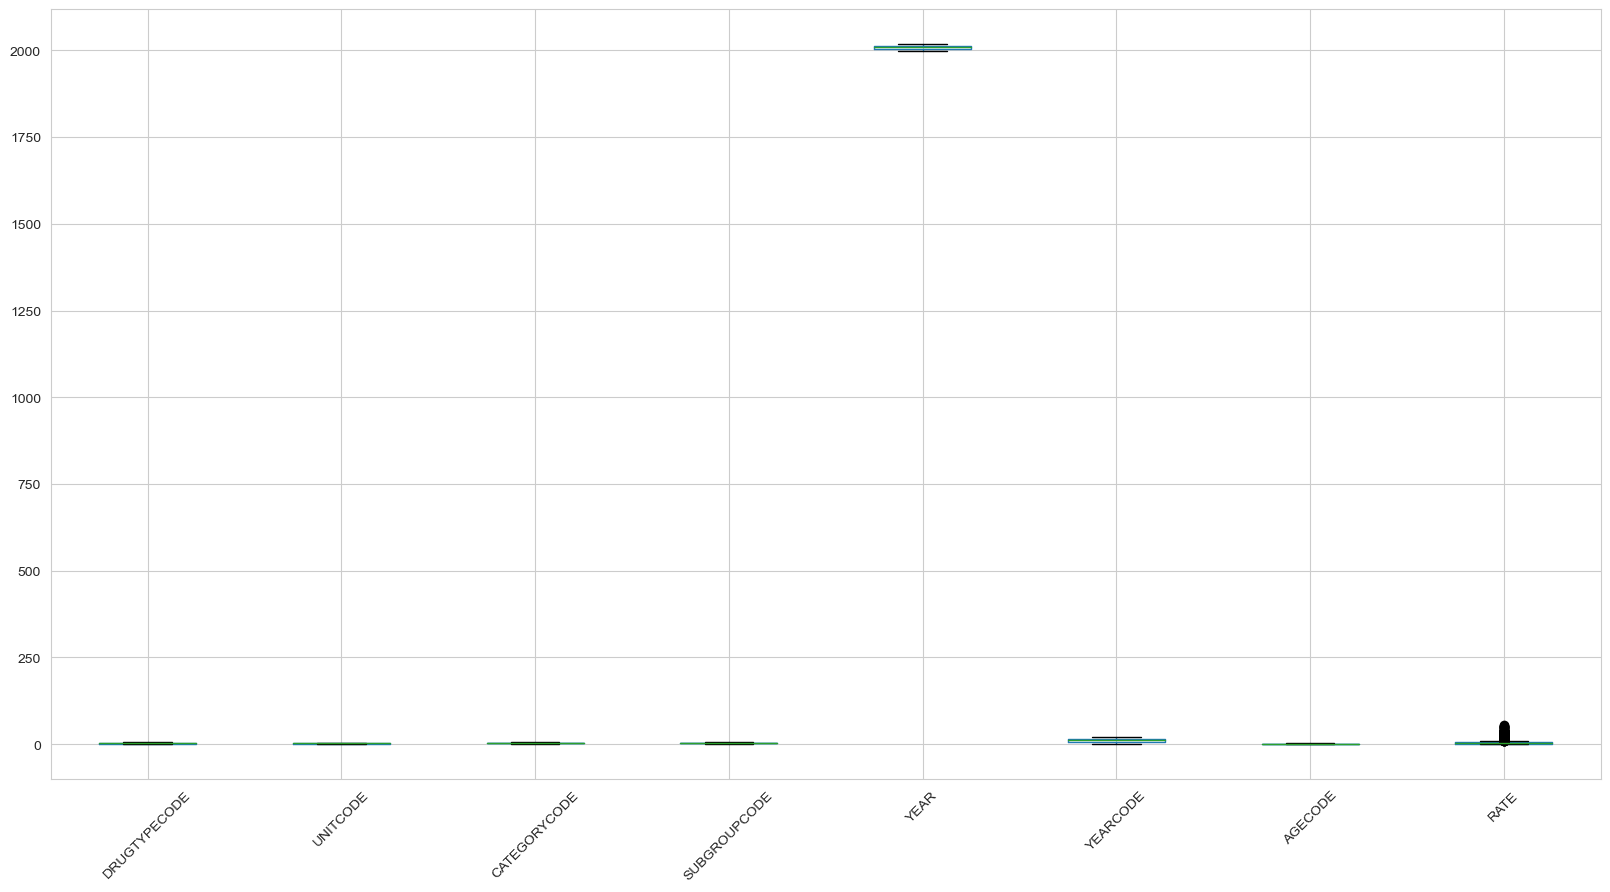

In [54]:
Q1 = df['RATE'].quantile(0.25)
Q3 = df['RATE'].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR
df.boxplot(figsize=(20,10))
plt.xticks(rotation=45)
plt.show()



In [55]:
#Basic information about the dataset
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6228 entries, 0 to 6227
Data columns (total 15 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   MEASURE       6228 non-null   object 
 1   DRUGTYPE      6228 non-null   object 
 2   DRUGTYPECODE  6228 non-null   int64  
 3   UNIT          6228 non-null   object 
 4   UNITCODE      6228 non-null   int64  
 5   CATEGORY      6228 non-null   object 
 6   CATEGORYCODE  6228 non-null   int64  
 7   SUBGROUP      6228 non-null   object 
 8   SUBGROUPCODE  6228 non-null   float64
 9   YEAR          6228 non-null   int64  
 10  YEARCODE      6228 non-null   int64  
 11  AGEGROUP      6228 non-null   object 
 12  AGECODE       6228 non-null   float64
 13  RATE          6228 non-null   float64
 14  FLAG          6228 non-null   object 
dtypes: float64(3), int64(5), object(7)
memory usage: 730.0+ KB
None


In [56]:
df['YEAR'] = df['YEAR'].astype('Int64')  
df['YEAR'] = pd.to_datetime(df['YEAR'], format='%Y')

In [57]:
print(df.describe())

       DRUGTYPECODE     UNITCODE  CATEGORYCODE  SUBGROUPCODE     YEARCODE  \
count   6228.000000  6228.000000   6228.000000   6228.000000  6228.000000   
mean       2.500000     1.578035      3.028902      3.383006    10.664740   
std        1.707962     0.493913      1.447036      1.526819     5.849512   
min        0.000000     1.000000      0.000000      0.100000     1.000000   
25%        1.000000     1.000000      2.000000      2.100000     6.000000   
50%        2.500000     2.000000      3.000000      3.220000    11.000000   
75%        4.000000     2.000000      4.000000      4.600000    16.000000   
max        5.000000     2.000000      5.000000      5.930000    20.000000   

           AGECODE         RATE  
count  6228.000000  6228.000000  
mean      1.354913     4.743443  
std       0.301459     5.823220  
min       1.100000     0.000000  
25%       1.100000     1.000000  
50%       1.200000     3.400000  
75%       1.600000     4.743443  
max       1.910000    54.300000  


In [58]:
df.columns


Index(['MEASURE', 'DRUGTYPE', 'DRUGTYPECODE', 'UNIT', 'UNITCODE', 'CATEGORY',
       'CATEGORYCODE', 'SUBGROUP', 'SUBGROUPCODE', 'YEAR', 'YEARCODE',
       'AGEGROUP', 'AGECODE', 'RATE', 'FLAG'],
      dtype='object')

In [59]:
# 1 What are the unique drug types, and how many records exist for each drug type?
print(df['DRUGTYPE'].value_counts())


All drug overdose deaths                                                         1038
Drug overdose deaths involving any opioid                                        1038
Drug overdose deaths involving natural and semisynthetic opioids                 1038
Drug overdose deaths involving methadone                                         1038
Drug overdose deaths involving other synthetic opioids (other than methadone)    1038
Drug overdose deaths involving heroin                                            1038
Name: DRUGTYPE, dtype: int64


In [60]:
# 2 What are the unique age groups, and how many records exist for each age group?
print(df['AGEGROUP'].value_counts())


All ages             2988
Under 15 years        360
15-24 years           360
25-34 years           360
35-44 years           360
45-54 years           360
55-64 years           360
65-74 years           360
75-84 years           360
85 years and over     360
Name: AGEGROUP, dtype: int64


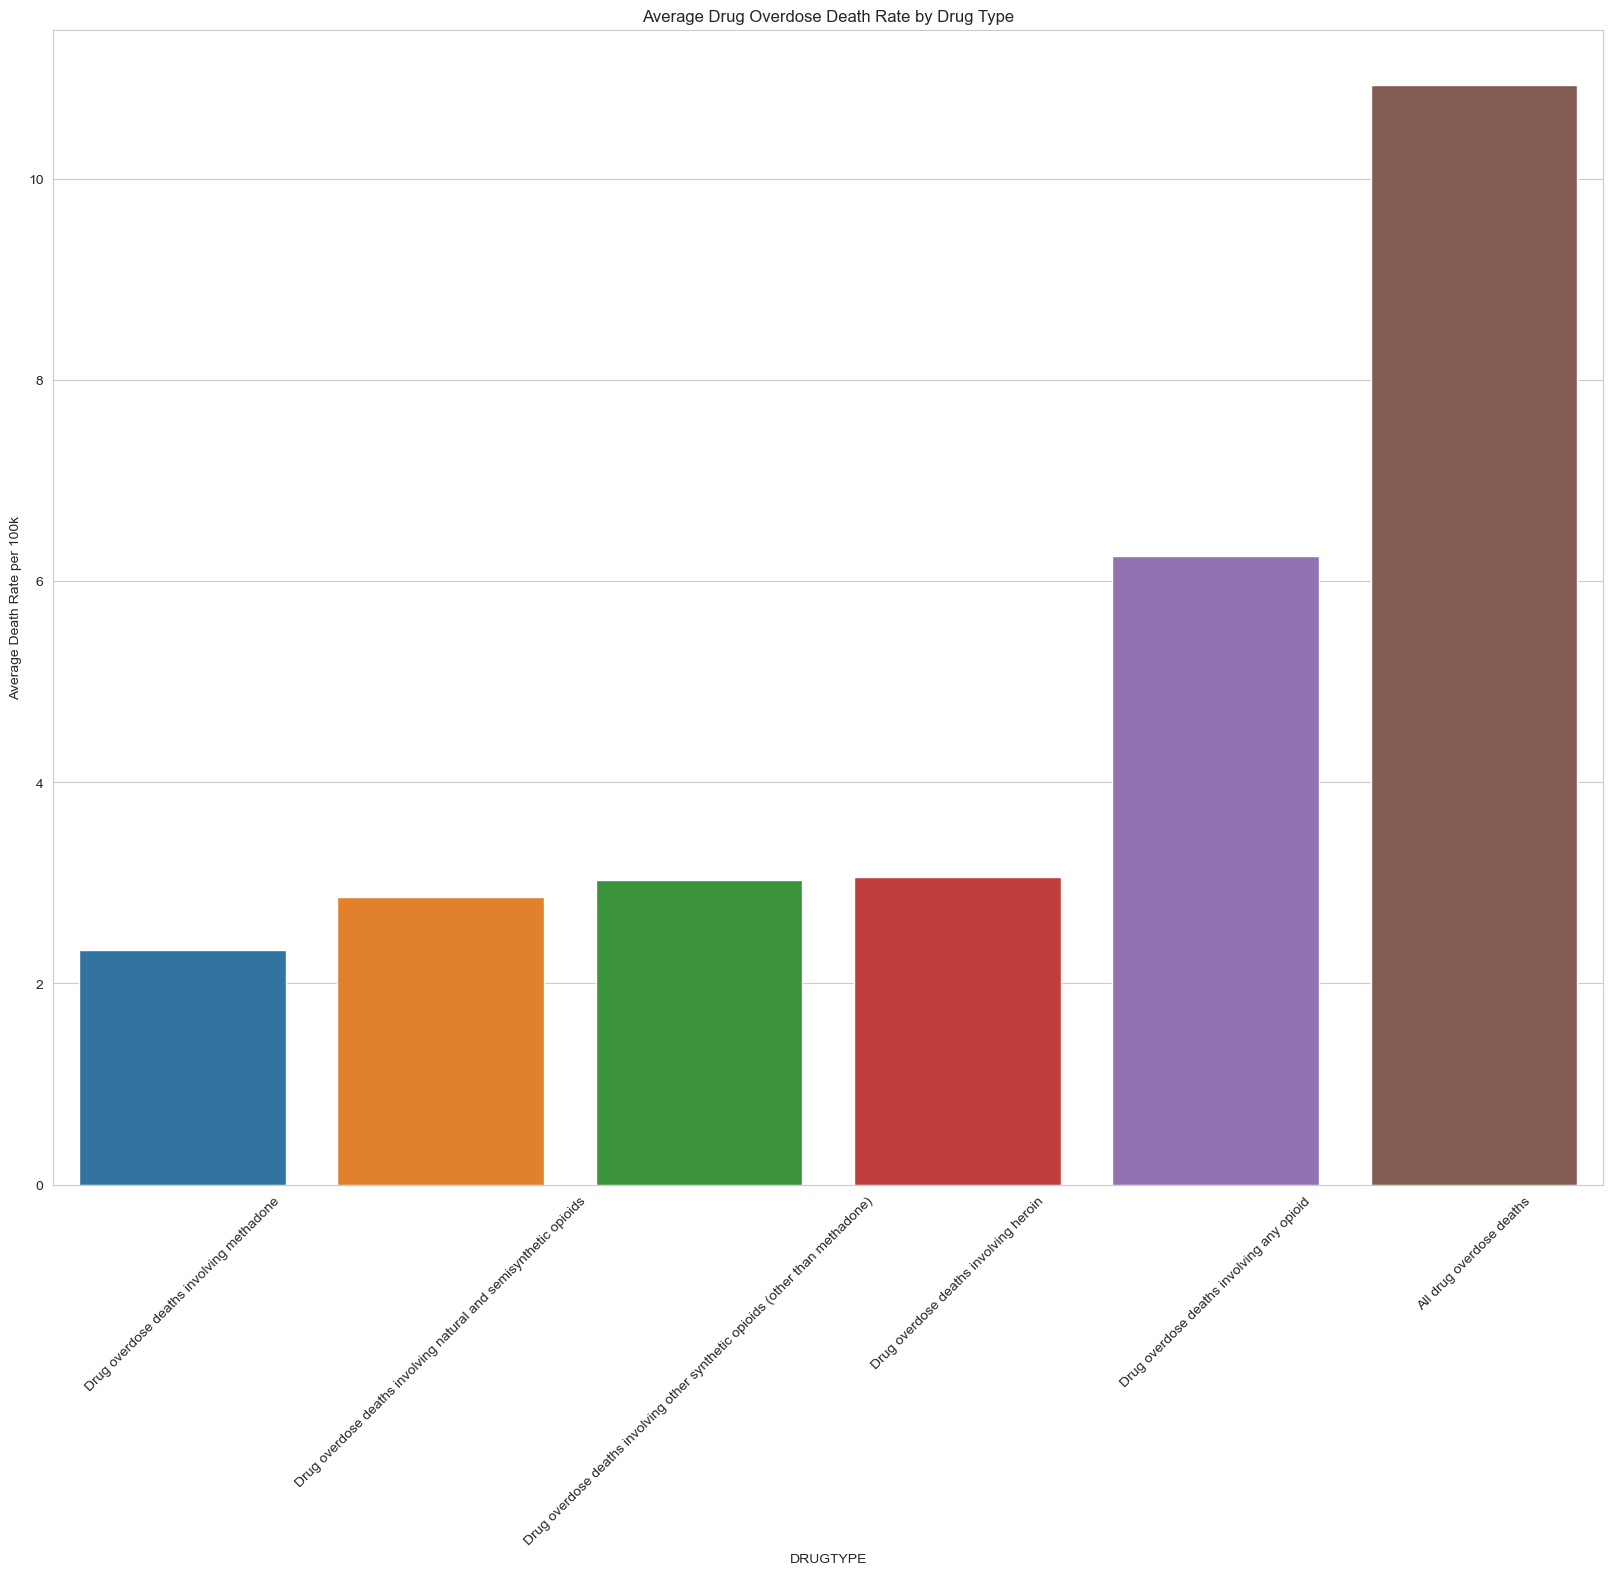

In [61]:
# 3
import matplotlib.pyplot as plt
import seaborn as sns
avg_rate = df.groupby('DRUGTYPE')['RATE'].mean().sort_values()

plt.figure(figsize=(20,15))
sns.barplot(x=avg_rate.index, y=avg_rate.values)
plt.xticks(rotation=45)
plt.ylabel("Average Death Rate per 100k")
plt.title("Average Drug Overdose Death Rate by Drug Type")
plt.show()


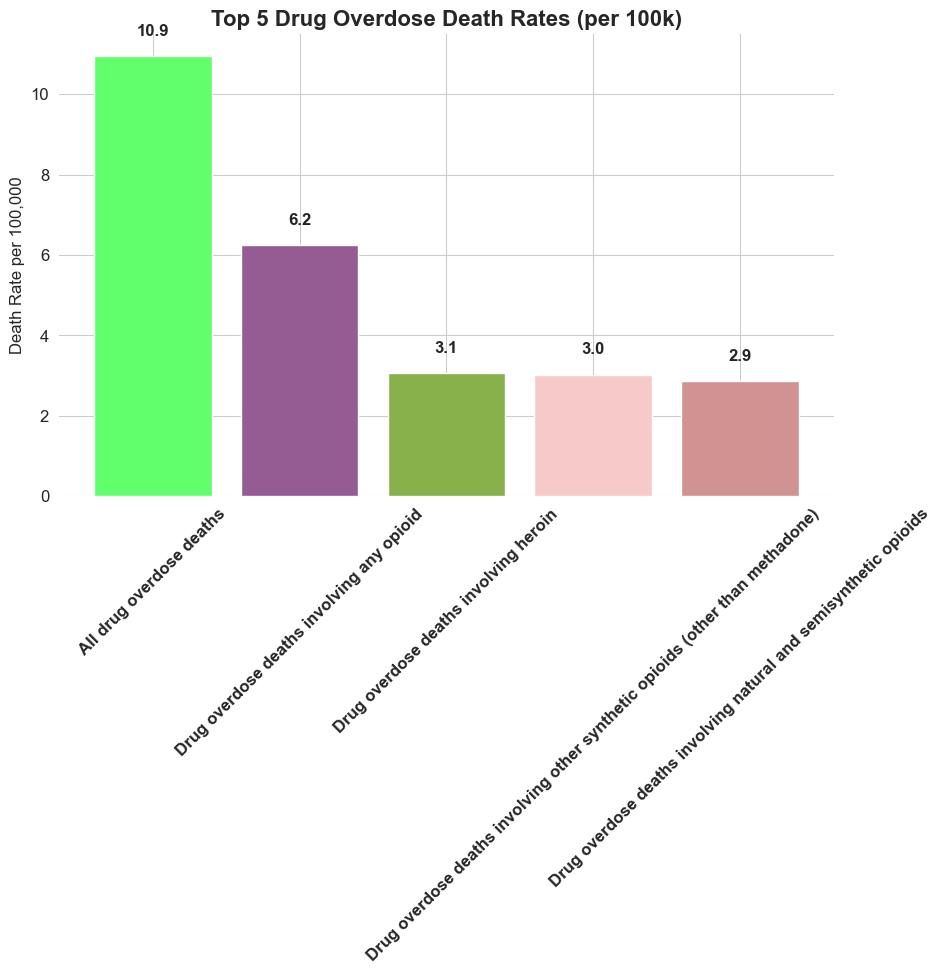

In [62]:
#4
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
top_drugs = df.groupby('DRUGTYPE')['RATE'].mean().sort_values(ascending=False).head(5)
sns.set_style("whitegrid")
plt.figure(figsize=(10,6))
bars = plt.bar(top_drugs.index, top_drugs.values, color=["#61ff6b","#955b93",'#88b04b','#f7cac9',"#d19292"])
plt.title("Top 5 Drug Overdose Death Rates (per 100k)", fontsize=16, weight='bold')
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 0.5, round(yval,1), ha='center', fontsize=12, weight='bold')
sns.despine(left=True, bottom=True)
plt.ylabel("Death Rate per 100,000", fontsize=12)
plt.xticks(rotation=45)
plt.xlabel("")
plt.xticks(fontsize=12, weight='bold')
plt.yticks(fontsize=12)
plt.show()


In [63]:
# 5 Average Drug Overdose Death Rate
avg_death_rate = df['RATE'].mean()
avg_death_rate


4.743443423881181

In [64]:
# 6 Maximum & Minimum Death Rate
max_rate = df['RATE'].max()
min_rate = df['RATE'].min()
max_rate, min_rate

(54.3, 0.0)

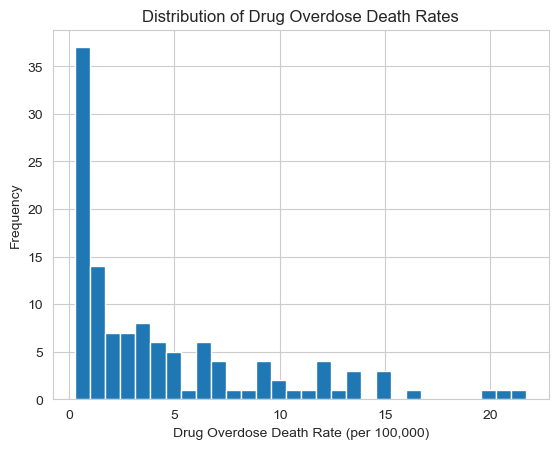

In [65]:
# 7 What does the shape of the histogram indicate about the distribution of drug overdose death rates?
df['RATE'] = pd.to_numeric(df['RATE'], errors='coerce')
filtered_df = df[
    (df['CATEGORY'] == 'Total') &
    (df['AGEGROUP'] == 'All ages') &
    (df['UNIT'].str.contains('age-adjusted', case=False, na=False))

]
plt.figure()
plt.hist(filtered_df['RATE'].dropna(), bins=30)
plt.xlabel('Drug Overdose Death Rate (per 100,000)')
plt.ylabel('Frequency')
plt.title('Distribution of Drug Overdose Death Rates')
plt.show()



In [66]:
# 8 Which drug type shows the highest average overdose death rate?
df['RATE'] = pd.to_numeric(df['RATE'], errors='coerce')

drug_risk = (df.groupby('DRUGTYPE')['RATE'].mean().sort_values(ascending=False))
print(drug_risk)


DRUGTYPE
All drug overdose deaths                                                         10.934242
Drug overdose deaths involving any opioid                                         6.244491
Drug overdose deaths involving heroin                                             3.060511
Drug overdose deaths involving other synthetic opioids (other than methadone)     3.029499
Drug overdose deaths involving natural and semisynthetic opioids                  2.861008
Drug overdose deaths involving methadone                                          2.330910
Name: RATE, dtype: float64


In [67]:
# 9 Which year has the highest average RATE?
year_risk = (df.groupby(['YEAR'])['RATE'].mean().sort_values(ascending=False))
year_risk.head(1)


YEAR
2017-01-01    8.23684
Name: RATE, dtype: float64

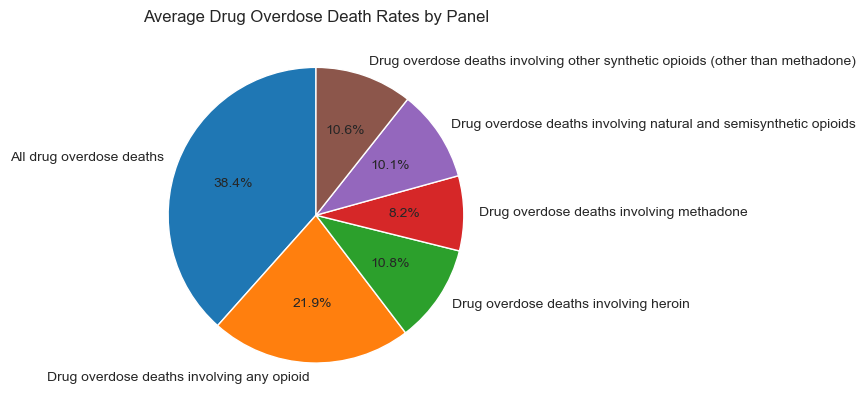

In [68]:
#  10 What percentage of average overdose death rates is contributed by each drug type?useing pie chart
df_clean = df.dropna(subset=['RATE'])
panel_data = df_clean.groupby("DRUGTYPE")['RATE'].mean()
plt.figure()
panel_data.plot(kind="pie", autopct="%1.1f%%", startangle=90)
plt.ylabel("")  
plt.title("Average Drug Overdose Death Rates by Panel")
plt.show()


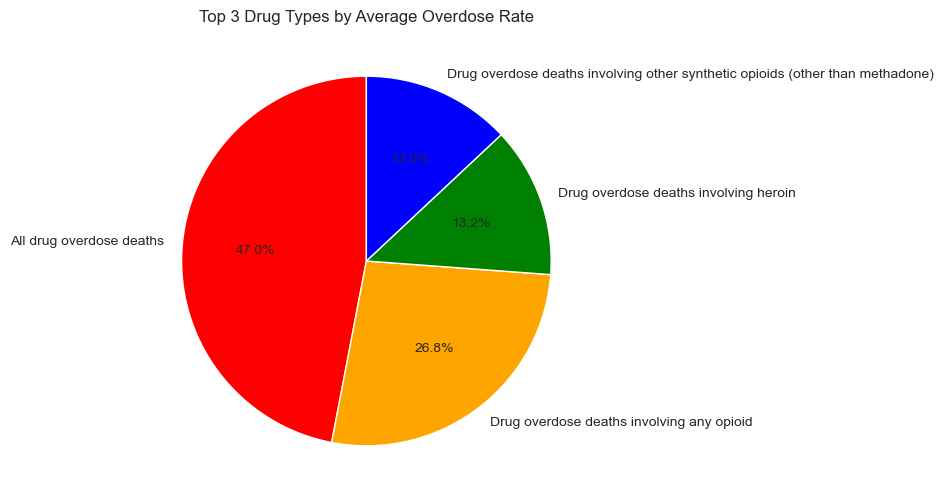

In [69]:
# Highlight top 3 drug types
top3 = panel_data.sort_values(ascending=False).head(4)
plt.figure(figsize=(6,6))
top3.plot(kind="pie", autopct="%1.1f%%", startangle=90, colors=['red','orange','green','blue'])
plt.ylabel("")
plt.title("Top 3 Drug Types by Average Overdose Rate")
plt.show()

In [70]:
df_clean = df.dropna(subset=['RATE'])
avg_rate_by_drug = df_clean.groupby('DRUGTYPE')['RATE'].mean()
lowest_drug = avg_rate_by_drug.idxmin()
lowest_rate = avg_rate_by_drug.min()

print(f"The drug type with the lowest average overdose death rate is '{lowest_drug}' with a rate of {lowest_rate:.2f} per 100,000 population.")

The drug type with the lowest average overdose death rate is 'Drug overdose deaths involving methadone' with a rate of 2.33 per 100,000 population.


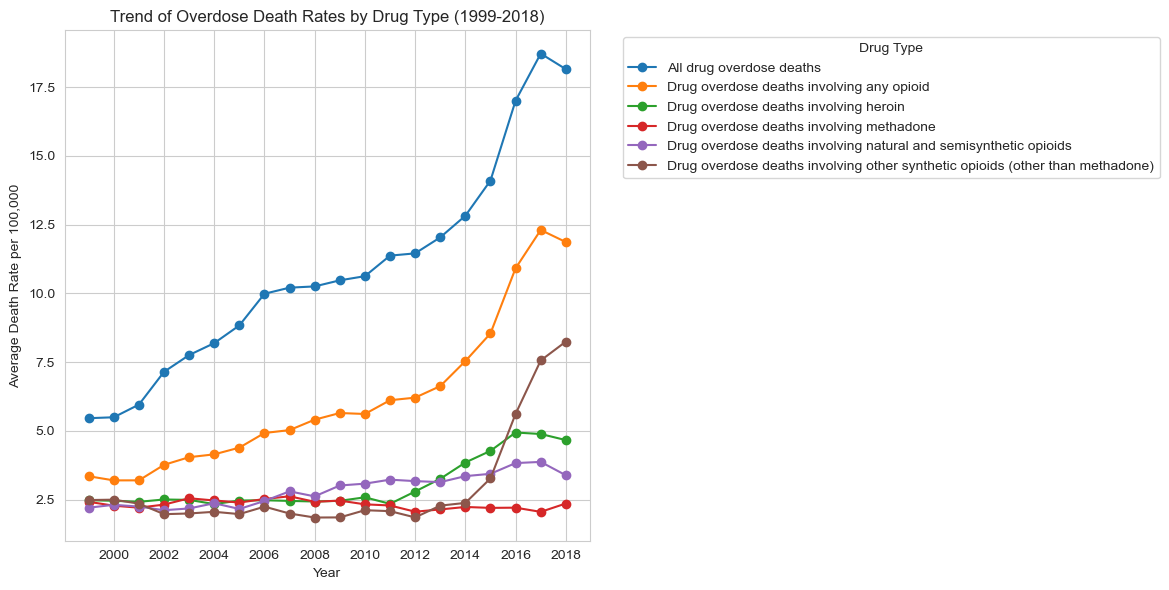

In [71]:
yearly_data = df_clean.groupby(['YEAR', 'DRUGTYPE'])['RATE'].mean().unstack()
plt.figure(figsize=(12,6))
for drug in yearly_data.columns:
    plt.plot(yearly_data.index,yearly_data[drug], marker='o', label=drug)

plt.title('Trend of Overdose Death Rates by Drug Type (1999-2018)')
plt.xlabel('Year')
plt.ylabel('Average Death Rate per 100,000')
plt.legend(title='Drug Type', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True)
plt.tight_layout()
plt.show()
















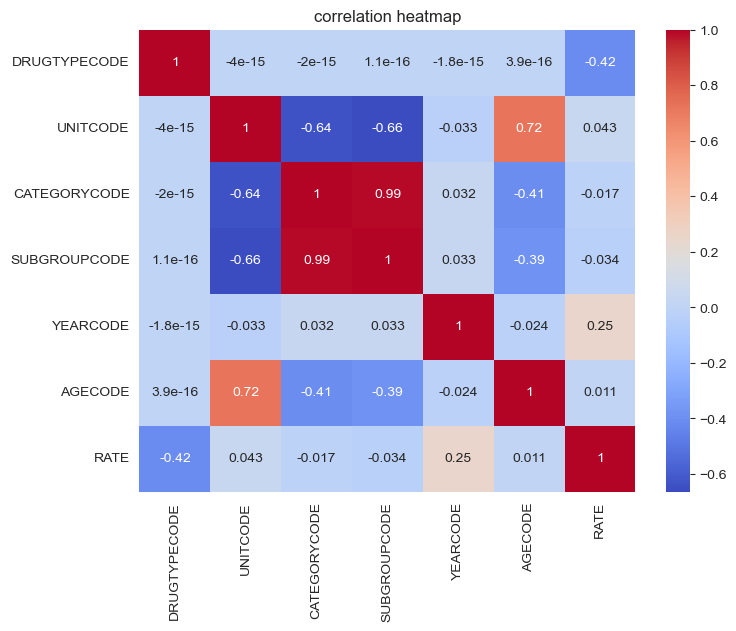

In [72]:
#12 heat map
plt.figure(figsize=(8,6))
sns.heatmap(df.corr(numeric_only=True),annot=True,cmap='coolwarm')
plt.title('correlation heatmap')
plt.show()

In [79]:
# 1. Extract year and create time features
df['Year'] = df['YEAR'].dt.year
df['Decade'] = (df['Year'] // 10) * 10
df['Post_2010'] = (df['Year'] >= 2010).astype(int)
df['Post_Epidemic'] = (df['Year'] >= 1999).astype(int)

# 2. Numeric conversions
df['RATE'] = pd.to_numeric(df['RATE'], errors='coerce')
df['AGECODE'] = pd.to_numeric(df['AGECODE'], errors='coerce')

# 3. Age features
df['Age_Lower'] = df['AGEGROUP'].str.extract(r'(\d+)').astype(float)
df['Age_Upper'] = df['AGEGROUP'].str.extract(r'(\d+)(?=\D*$)').astype(float)
df['Is_Youth'] = df['Age_Lower'].between(0, 24).astype(int)
df['Is_Adult'] = df['Age_Lower'].between(25, 64).astype(int)
df['Is_Senior'] = (df['Age_Lower'] >= 65).astype(int)

# 4. Drug type flags
df['Is_Opioid'] = df['DRUGTYPE'].str.contains("opioid|heroin|synthetic", case=False, na=False).astype(int)
df['Is_Heroin'] = df['DRUGTYPE'].str.contains("heroin", case=False, na=False).astype(int)
df['Is_Cocaine'] = df['DRUGTYPE'].str.contains("cocaine", case=False, na=False).astype(int)
df['Is_Synthetic'] = df['DRUGTYPE'].str.contains("synthetic", case=False, na=False).astype(int)

# 5. Lag and change features
df = df.sort_values(by=['DRUGTYPE', 'Year'])
df['Lag_1'] = df.groupby('DRUGTYPE')['RATE'].shift(1)
df['Change'] = df['RATE'] - df['Lag_1']
df['Pct_Change'] = df['Change'] / (df['Lag_1'] + 1e-5)

# 6. Encode categorical features
df['Drug_Code'] = df['DRUGTYPE'].astype('category').cat.codes
df['Unit_Code'] = df['UNIT'].astype('category').cat.codes
df['Subgroup_Code'] = df['SUBGROUP'].astype('category').cat.codes
df['Age_Code'] = df['AGEGROUP'].astype('category').cat.codes

print(df.head())


                      MEASURE                  DRUGTYPE  DRUGTYPECODE  \
0   Drug overdose death rates  All drug overdose deaths             0   
19  Drug overdose death rates  All drug overdose deaths             0   
39  Drug overdose death rates  All drug overdose deaths             0   
58  Drug overdose death rates  All drug overdose deaths             0   
78  Drug overdose death rates  All drug overdose deaths             0   

                                                 UNIT  UNITCODE      CATEGORY  \
0   Deaths per 100,000 resident population, age-ad...         1         Total   
19  Deaths per 100,000 resident population, age-ad...         1           Sex   
39  Deaths per 100,000 resident population, age-ad...         1           Sex   
58  Deaths per 100,000 resident population, age-ad...         1  Sex and race   
78  Deaths per 100,000 resident population, age-ad...         1  Sex and race   

    CATEGORYCODE                         SUBGROUP  SUBGROUPCODE       YEAR

### Suggestions & Recommendations

1. Rising Overdose Rates

Observation: Overall drug overdose deaths are increasing over time, with sharp rises in opioids, heroin, and synthetic drugs.

Recommendation:

Monitor yearly trends to detect spikes early.

Focus prevention efforts on high-risk drugs.

2. High-Risk Drugs

Observation: Opioids, heroin, and synthetic drugs cause the majority of deaths.

Recommendation:

Prioritize interventions and treatment for these drugs.

Track emerging synthetic drugs closely.

3. Age Vulnerability

Observation: Adults (25–64) have the highest rates; seniors are also increasing; youth are less affected but show rising opioid trends.

Recommendation:

Target public health programs by age group.

Create awareness campaigns for vulnerable populations.

4. Temporal Trends

Observation: Overdose rates rise significantly after 2010 and vary by age and drug type.

Recommendation:

Use year and decade data to forecast future trends.

Identify at-risk subgroups for timely interventions.

5. Predictive Monitoring

Observation: Lagged rates and percent change can indicate upcoming surges